In [3]:
# ==========================================================
# Cell 1 : Import Libraries
# ==========================================================

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
os.makedirs("../images", exist_ok=True)

df = pd.read_csv(
    "../data/processed/retail_clean.csv",
    parse_dates=["Order_Date"]
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (20000, 13)


,Order_ID,Order_Date,Customer_ID,Product_ID,Category,Region,Quantity,Unit_Price,Discount,Sub_Category,Sales,Cost,Profit
0,ORD100000,2024-05-10,CUST01487,PROD0029,Beauty,Central,7,29.35,0.26,Skincare,152.03,98.82,53.21
1,ORD100001,2024-11-10,CUST00042,PROD0026,Grocery,North,7,247.81,0.07,Snacks,1613.24,1048.61,564.63
2,ORD100002,2022-05-02,CUST01197,PROD0070,Beauty,East,1,365.99,0.09,Makeup,333.05,216.48,116.57
3,ORD100003,2023-04-12,CUST00679,PROD0011,Beauty,South,2,269.54,0.16,Haircare,452.83,294.34,158.49
4,ORD100004,2022-11-27,CUST01274,PROD0100,Grocery,West,5,163.63,0.13,Dairy,711.79,462.66,249.13


In [4]:
# ==========================================================
# Cell 2 : Feature Engineering
# ==========================================================

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Day"] = df["Order_Date"].dt.day
df["Weekday"] = df["Order_Date"].dt.weekday
df["Quarter"] = df["Order_Date"].dt.quarter

features = [
    "Year",
    "Month",
    "Day",
    "Weekday",
    "Quarter",
    "Quantity",
    "Discount",
    "Unit_Price"
]

X = df[features]
y = df["Sales"]

In [5]:
# ==========================================================
# Cell 3 : Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16000, 8)
(4000, 8)


In [6]:
# ==========================================================
# Cell 4 : XGBoost Forecast Model
# ==========================================================

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

model.fit(X_train, y_train)

joblib.dump(
    model,
    "../models/sales_forecasting.pkl"
)

print("Forecast Model Saved!")

Forecast Model Saved!


In [7]:
# ==========================================================
# Cell 5 : Evaluation
# ==========================================================

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 8.30
RMSE : 11.84
R²   : 0.9998


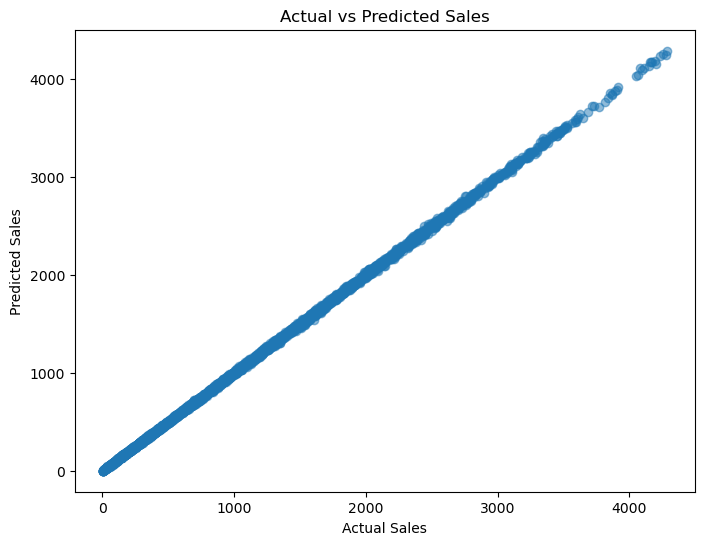

In [8]:
# ==========================================================
# Cell 6 : Visualization
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.savefig(
    "../images/sales_forecast.png",
    dpi=300
)

plt.show()

In [9]:
# ==========================================================
# Cell 7 : Future Sales Forecast
# ==========================================================

future_dates = pd.date_range(
    df["Order_Date"].max() + pd.Timedelta(days=1),
    periods=30
)

future = pd.DataFrame()

future["Order_Date"] = future_dates
future["Year"] = future_dates.year
future["Month"] = future_dates.month
future["Day"] = future_dates.day
future["Weekday"] = future_dates.weekday
future["Quarter"] = future_dates.quarter

future["Quantity"] = df["Quantity"].mean()
future["Discount"] = df["Discount"].mean()
future["Unit_Price"] = df["Unit_Price"].mean()

future["Forecast_Sales"] = model.predict(
    future[features]
)

future.to_csv(
    "../reports/30_day_sales_forecast.csv",
    index=False
)

display(future.head())

,Order_Date,Year,Month,Day,Weekday,Quarter,Quantity,Discount,Unit_Price,Forecast_Sales
0,2024-12-31,2024,12,31,1,4,5.00525,0.149542,252.670572,1087.886230
1,2025-01-01,2025,1,1,2,1,5.00525,0.149542,252.670572,1085.484497
2,2025-01-02,2025,1,2,3,1,5.00525,0.149542,252.670572,1087.557129
3,2025-01-03,2025,1,3,4,1,5.00525,0.149542,252.670572,1088.152222
4,2025-01-04,2025,1,4,5,1,5.00525,0.149542,252.670572,1088.152222


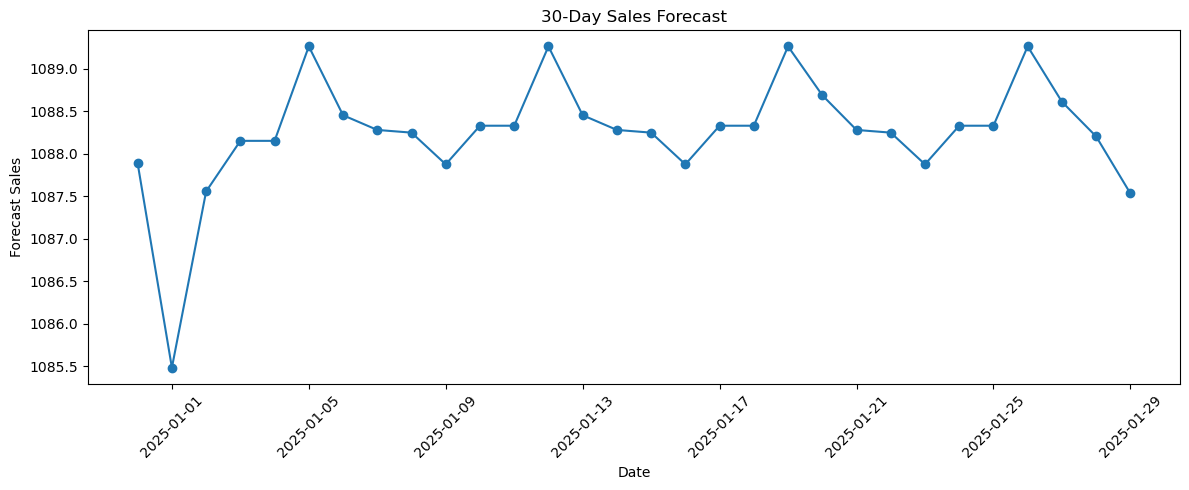

In [10]:
# ==========================================================
# Cell 8 : Forecast Graph
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(
    future["Order_Date"],
    future["Forecast_Sales"],
    marker="o"
)

plt.title("30-Day Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Forecast Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/30_day_forecast.png",
    dpi=300
)

plt.show()